# Dacon E-Commerce Dataset - Gold 등급 세부 분석

---

## 분석 개요

RFM 세그먼테이션에서 도출된 **Gold(재방문율 74.1%)** 를 대상으로 재구매 패턴과 이탈 위험군을 심층 분석하고, 충성도 제고 및 상위 등급 전환 전략을 제시한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Gold |
| 분석 기간 | 2019-01-01 - 2019-12-31 |
| Gold | 243명 (16.56%) |
| 매출 기여 | 전체 매출의 24.34% |

---

## 등급 프로파일

RFM 점수(20-100)는 R·F·M 점수(각 1-5)에 PCA 가중치(R 20.1% / F 33.9% / M 46.0%)를 적용해 산출한다.

| | Gold |
|---|---|
| RFM 점수 기준 | 65점 이상 - 80점 미만 |
| 재방문율 | 74.1% |
| 1인당 지출 | `$4,831` |

### 세그먼트 구성

| 세그먼트 | 비중 | 그룹 | 정의 |
|---------|:----:|------|------|
| 충성 고객 | **18.9%** | 안정군 | 지속적이고 안정적인 구매 패턴 (F·M 중상위) |
| 잠재 충성 고객 | 26.7% | 안정군 | 최근 구매 이력 있음, 충성 고객으로 성장 가능성 높음 |
| 관심 필요 고객 | 21.0% | 이탈 위험군 | 평균 수준이나 최근성이 떨어지기 시작 (R 감소 조짐) |
| 이탈 위험 고객 | 18.1% | 이탈 위험군 | 과거 고빈도였지만 최근 방문 감소 (R 낮음) |
| 놓치면 안될 고객 | 15.2% | 이탈 위험군 | 과거 고가치이나 오랫동안 구매 없음 (F·M 높음, R 낮음) |

---

## 분석 배경

Gold는 전체 고객의 16.56%(243명)으로 전체 매출의 24.34%를 담당하는 핵심 중간층이다.  
재방문율 74.1%로 상위 등급(Diamond 94.8%, Platinum 88.3%) 대비 14-21%p 낮으며,  
안정군(충성 18.9% + 잠재 충성 26.7% = 45.6%)과 이탈 위험군(54.3%)이 공존하고 있다.

---

## 핵심 질문

**왜 상위 등급보다 재방문이 적은가? 누가 이탈하고, 누가 올라갈 수 있는가?**

| 가설 | 내용 |
|------|------|
| 가설 1 | Gold의 낮은 재방문율은 이탈 위험군(54.3%)이 주도할 것이다 |
| 가설 2 | '놓치면 안될' 고객은 Gold 내 최고 구매금액을 보이지만 가장 오래 침묵 중일 것이다 |
| 가설 3 | 잠재 충성 고객은 F·M 부족으로 Platinum 전환까지 Gold 내 갭이 가장 클 것이다 |
| 가설 4 | Gold 고객의 이탈 시점은 랜덤하지 않고 특정 월에 집중될 것이다 |
| 가설 4-1 | Gold 내 이탈 조짐 고객은 RFM 점수 하한(65점쪽, 겨우 Gold)에 더 많이 집중될 것이다 |

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

# 분석 SQL은 ../sql/06_segment_gold.sql 에 모으고 `-- name:` 마커로 구분한다.
import re
from pathlib import Path
from sqlalchemy import text

SQL_FILE = Path('../sql/06_segment_gold.sql')

def load_queries(path):
    """`-- name: 이름 | 설명` 마커로 SQL을 쪼개 {이름: 쿼리}로 반환."""
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, **kwargs):
    """이름으로 SELECT 쿼리를 실행해 DataFrame 반환."""
    return pd.read_sql(Q[name], engine, **kwargs)

def execute(name):
    """이름으로 DDL(세미콜론 구분)을 실행."""
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

---
## 데이터 로드

`rfm_result` 테이블에 저장된 세그먼트를 JOIN하여 Gold 고객의 RFM 지표와 세그먼트를 한 번에 로드한다.

In [2]:
gold_rfm = run('gold_rfm')

gold_rfm.head()

,고객ID,세그먼트,Recency,Frequency,Monetary,R,F,M,RFM_score
0,USER_0006,이탈 위험 고객,189,44,7344.28,2,4,4,71.956632
1,USER_0015,잠재 충성 고객,10,14,2464.38,5,3,3,68.043368
2,USER_0018,관심 필요 고객,140,24,2935.79,3,4,3,66.778626
3,USER_0028,잠재 충성 고객,17,14,2628.80,5,3,3,68.043368
4,USER_0036,잠재 충성 고객,33,13,3157.04,5,3,3,68.043368


In [3]:
gold_rfm.shape

(243, 9)

In [4]:
gold_rfm.describe()

,Recency,Frequency,Monetary,R,F,M,RFM_score
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,124.555556,26.353909,4831.450000,3.329218,3.592593,3.625514,71.095513
std,107.038612,10.048141,2212.647198,1.518022,0.516931,0.533667,3.721333
min,0.000000,12.000000,1815.460000,1.000000,3.000000,3.000000,65.178005
25%,28.000000,19.000000,3310.170000,2.000000,3.000000,3.000000,68.043368
50%,108.000000,25.000000,4473.230000,3.000000,4.000000,4.000000,70.800311
75%,188.500000,32.000000,6074.950000,5.000000,4.000000,4.000000,74.821995
max,362.000000,69.000000,23074.440000,5.000000,5.000000,5.000000,78.735258


In [5]:
seg_color_gold = {
    '충성 고객': '#66bd63',
    '잠재 충성 고객': '#a6d96a',
    '관심 필요 고객': '#fdae61',
    '이탈 위험 고객': '#e74c3c',
    '놓치면 안될 고객': '#9b59b6',
}

seg_group_map = {
    '충성 고객': '안정군',
    '잠재 충성 고객': '안정군',
    '관심 필요 고객': '이탈 위험군',
    '이탈 위험 고객': '이탈 위험군',
    '놓치면 안될 고객': '이탈 위험군',
}

print(f'Gold 고객 수: {len(gold_rfm):,}명')
gold_rfm['세그먼트'].value_counts()

Gold 고객 수: 243명


세그먼트
잠재 충성 고객     65
관심 필요 고객     51
충성 고객        46
이탈 위험 고객     44
놓치면 안될 고객    37
Name: count, dtype: int64

In [6]:
seg_overview = (
    gold_rfm.groupby('세그먼트')
    .agg(
        고객수=('고객ID', 'count'),
        R_평균=('R', 'mean'),
        F_평균=('F', 'mean'),
        M_평균=('M', 'mean'),
        R_중앙값=('R', 'median'),
        F_중앙값=('F', 'median'),
        M_중앙값=('M', 'median'),
        RFM_score_중앙값=('RFM_score', 'median'),
        Recency_중앙값=('Recency', 'median'),
        Frequency_중앙값=('Frequency', 'median'),
        Monetary_중앙값=('Monetary', 'median')
    )
    .round(2)
    .reset_index()
)
seg_overview['그룹'] = seg_overview['세그먼트'].map(seg_group_map)
seg_overview = seg_overview.sort_values('RFM_score_중앙값', ascending=False).reset_index(drop=True)
seg_overview

,세그먼트,고객수,R_평균,F_평균,M_평균,R_중앙값,F_중앙값,M_중앙값,RFM_score_중앙값,Recency_중앙값,Frequency_중앙값,Monetary_중앙값,그룹
0,충성 고객,46,3.43,3.96,3.83,3.0,4.0,4.0,75.98,115.5,32.0,5312.32,안정군
1,관심 필요 고객,51,4.02,3.43,3.57,4.0,3.0,4.0,73.22,69.0,22.0,4142.43,이탈 위험군
2,이탈 위험 고객,44,1.91,3.91,4.09,2.0,4.0,4.0,71.96,190.5,32.0,6169.04,이탈 위험군
3,잠재 충성 고객,65,5.00,3.00,3.00,5.0,3.0,3.0,68.04,20.0,15.0,2789.52,안정군
4,놓치면 안될 고객,37,1.00,4.03,4.00,1.0,4.0,4.0,67.93,316.0,32.0,5713.83,이탈 위험군


---
## 가설 1 — Gold 등급의 상위 등급 대비 낮은 재방문율은 이탈 위험군이 주도할 것이다

> **가설 1**: Gold의 재방문율(74.1%)이 D·P(88%+) 대비 낮은 원인은 **이탈 위험군**(관심 필요, 이탈 위험, 놓치면 안될 고객 비율 = 54.3%)의 낮은 재방문 빈도에 있을 것이다.
>
> - 근거: rfm_segmentation에서 확인된 Gold 세그먼트 구성 — 54.3%가 이탈 위험 세그먼트
> - 검증: 세그먼트별 재방문율 비교 및 안정군 vs 이탈 위험군 Recency 분포 비교

In [7]:
visit_days = run('visit_days_all')

visit_days['재방문횟수'] = visit_days['방문일수'] - 1
visit_h1 = visit_days.merge(gold_rfm[['고객ID', '세그먼트', 'Recency', 'R']], on='고객ID')
visit_h1.head()

,고객ID,방문일수,재방문횟수,세그먼트,Recency,R
0,USER_0006,2,1,이탈 위험 고객,189,2
1,USER_0015,1,0,잠재 충성 고객,10,5
2,USER_0018,3,2,관심 필요 고객,140,3
3,USER_0028,3,2,잠재 충성 고객,17,5
4,USER_0036,2,1,잠재 충성 고객,33,5


In [8]:
seg_revisit = (
    visit_h1.groupby('세그먼트')
    .agg(
        재방문고객=('재방문횟수', lambda x: (x >= 1).sum()),
        전체고객=('재방문횟수', 'count')
    )
    .assign(재방문율=lambda x: (x['재방문고객'] / x['전체고객'] * 100).round(1))
    .reset_index()
    .sort_values('재방문율', ascending=False)
)

visit_h1['그룹'] = visit_h1['세그먼트'].map(seg_group_map)
seg_revisit

,세그먼트,재방문고객,전체고객,재방문율
4,충성 고객,40,46,87.0
2,이탈 위험 고객,38,44,86.4
0,관심 필요 고객,36,51,70.6
3,잠재 충성 고객,45,65,69.2
1,놓치면 안될 고객,21,37,56.8


In [9]:
seg_h1_stats = (
    visit_h1.groupby('세그먼트')[['Recency', 'R']]
    .agg(['mean', 'median'])
    .round(1)
    .reset_index()
)
seg_h1_stats.columns = ['세그먼트', 'Recency_평균', 'Recency_중앙값', 'R_평균', 'R_중앙값']
seg_h1_stats = (
    seg_h1_stats
    .merge(seg_revisit[['세그먼트', '재방문율']], on='세그먼트')
    .sort_values('재방문율', ascending=False)
    .reset_index(drop=True)
)
seg_h1_stats

,세그먼트,Recency_평균,Recency_중앙값,R_평균,R_중앙값,재방문율
0,충성 고객,105.1,115.5,3.4,3.0,87.0
1,이탈 위험 고객,203.0,190.5,1.9,2.0,86.4
2,관심 필요 고객,68.1,69.0,4.0,4.0,70.6
3,잠재 충성 고객,21.5,20.0,5.0,5.0,69.2
4,놓치면 안될 고객,314.4,316.0,1.0,1.0,56.8


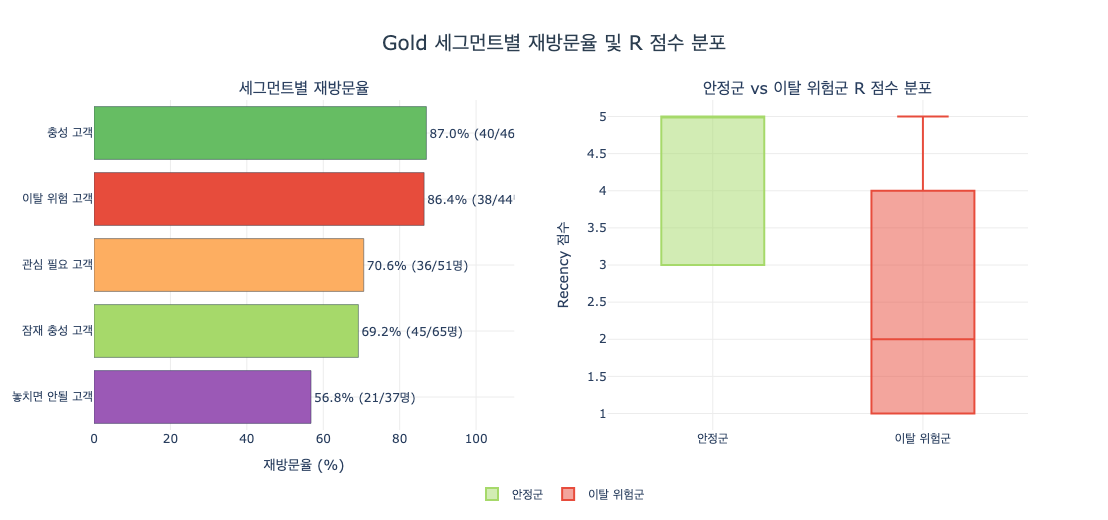

In [10]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['세그먼트별 재방문율', '안정군 vs 이탈 위험군 R 점수 분포']
)

for _, row in seg_revisit.sort_values('재방문율').iterrows():
    fig.add_trace(go.Bar(
        x=[row['재방문율']],
        y=[row['세그먼트']],
        orientation='h',
        marker=dict(
            color=seg_color_gold.get(row['세그먼트'], '#dfe6e9'),
            line=dict(color='#2c3e50', width=0.5)
        ),
        text=[f"{row['재방문율']:.1f}% ({int(row['재방문고객'])}/{int(row['전체고객'])}명)"],
        textposition='outside',
        showlegend=False,
        name=row['세그먼트']
    ), row=1, col=1)

for group, color in [('안정군', '#a6d96a'), ('이탈 위험군', '#e74c3c')]:
    sub = visit_h1[visit_h1['그룹'] == group]['R']
    fig.add_trace(go.Box(
        y=sub,
        name=group,
        marker_color=color,
        boxpoints='outliers',
        showlegend=True
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Gold 세그먼트별 재방문율 및 R 점수 분포',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    width=1500,
    height=520,
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='재방문율 (%)', range=[0, 110], row=1, col=1)
fig.update_yaxes(title_text='Recency 점수', row=1, col=2)
fig.show()

> ### 가설 1 검증 결과: 부분 기각
>
> | 세그먼트 | 재방문율 | R 평균 | R 중앙값 | Recency 평균 | Recency 중앙값 | 그룹 |
> | :--- | :---: | :---: | :---: | :---: | :---: | :--- |
> | 충성 고객 | **87.0%** | 3.4 | 3.0 | 105.1일 | 115.5일 | 안정군 |
> | 이탈 위험 고객 | 86.4% | 1.9 | 2.0 | 203.0일 | 190.5일 | 이탈 위험군 |
> | 관심 필요 고객 | 70.6% | 4.0 | 4.0 | 68.1일 | 69.0일 | 이탈 위험군 |
> | 잠재 충성 고객 | 69.2% | 5.0 | 5.0 | 21.5일 | 20.0일 | 안정군 |
> | 놓치면 안될 고객 | **56.8%** | 1.0 | **1.0** | 314.4일 | **316.0일** | 이탈 위험군 |
>
> **핵심 요약**
> Gold 등급의 낮은 재방문율(74.1%)은 이탈 위험군 전체의 문제가 아닌, **세그먼트별 상이한 원인이 결합된 복합 구조**로 나타났다.
>
> - **놓치면 안될 고객 (재방문율 56.8% | R=1.0)**
>   - **현황**: Gold 전체의 재방문율을 갉아먹는 **핵심 원인 집단**이다.
>   - **데이터 특징**: Recency 평균(314.4일)과 중앙값(316.0일)이 거의 일치한다. 이는 특정 아웃라이어가 아닌, **구성원 대부분이 고르게 10개월 이상 장기 침묵 상태**에 빠져 있음을 뜻한다.
>
> - **이탈 위험 고객 (재방문율 86.4% | Recency 중앙값 190.5일)**
>   - **현황**: 가설과 달리 충성 고객(87.0%)에 버금가는 **높은 재방문율**을 기록했다.
>   - **데이터 특징**: 평균(203.0일)이 중앙값보다 약 12일 높다. 즉, 소수의 극단적 장기 미방문자가 평균을 끌어올렸을 뿐, **대다수는 190일 수준의 안정적인 분포**를 보인다. 연초-연중에 활발히 활동하다 하반기에 일시적으로 침묵한 구조로 해석된다.
>
> - ⚠️ **잠재 충성(69.2%) & 관심 필요(70.6%)**
>   - 두 집단 모두 평균과 중앙값이 거의 일치하여 분포가 매우 고르며, Gold 평균보다 낮은 재방문율을 보이며 전체 지표 하락에 소폭 기여한다.

---
## 가설 2 — '놓치면 안될' 고객은 Gold 내 최고 구매금액이지만 가장 오래 침묵 중일 것이다

> **가설 2**: '놓치면 안될' 세그먼트(중앙값 기준 R=1, F=4, M=4)는 과거 고가치 구매자가 최근 구매를 중단한 상태로, Gold 내에서 Monetary가 가장 높지만 Recency도 가장 길 것이다.
>
> - 근거: 세그먼트 정의상 F·M=4이나 R=1 — D·P의 이탈 조짐 분석에서 확인된 역설(고가치 + 최근 침묵)과 유사한 구조
> - 검증: 세그먼트별 Recency 중앙값 vs Monetary 중앙값 비교

In [11]:
seg_summary = (
    gold_rfm.groupby('세그먼트')[['Recency', 'Frequency', 'Monetary']]
    .agg(['median', 'mean'])
    .round(1)
    .reset_index()
)
seg_summary.columns = [
    '세그먼트',
    'Recency_중앙값', 'Recency_평균',
    'Frequency_중앙값', 'Frequency_평균',
    'Monetary_중앙값', 'Monetary_평균'
]
seg_summary = seg_summary.sort_values('Monetary_중앙값', ascending=False).reset_index(drop=True)
seg_summary

,세그먼트,Recency_중앙값,Recency_평균,Frequency_중앙값,Frequency_평균,Monetary_중앙값,Monetary_평균
0,이탈 위험 고객,190.5,203.0,32.0,33.4,6169.0,6579.4
1,놓치면 안될 고객,316.0,314.4,32.0,32.8,5713.8,6173.8
2,충성 고객,115.5,105.1,32.0,32.9,5312.3,5450.0
3,관심 필요 고객,69.0,68.1,22.0,22.8,4142.4,4335.9
4,잠재 충성 고객,20.0,21.5,15.0,16.0,2789.5,2835.3


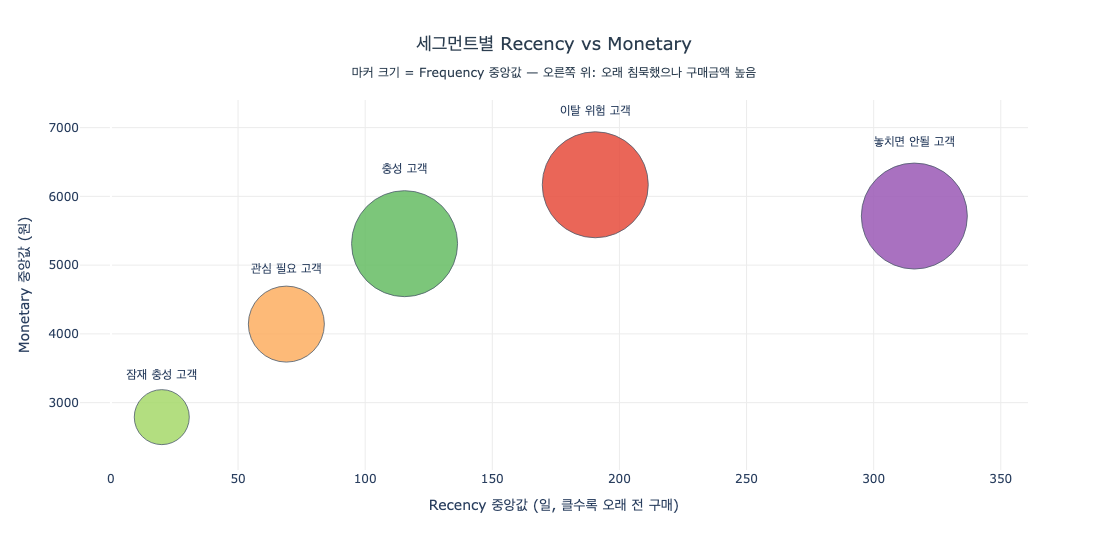

In [12]:
fig = go.Figure()
for _, row in seg_summary.iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Scatter(
        x=[row['Recency_중앙값']],
        y=[row['Monetary_중앙값']],
        mode='markers+text',
        marker=dict(
            size=row['Frequency_중앙값'] * 3 + 10,
            color=seg_color_gold.get(seg, '#dfe6e9'),
            line=dict(color='#2c3e50', width=0.8),
            opacity=0.85
        ),
        text=[seg],
        textposition='top center',
        name=seg
    ))

fig.update_layout(
    title=dict(
        text='세그먼트별 Recency vs Monetary<br><sub>마커 크기 = Frequency 중앙값 — 오른쪽 위: 오래 침묵했으나 구매금액 높음</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Recency 중앙값 (일, 클수록 오래 전 구매)', gridcolor='#ececec'),
    yaxis=dict(title='Monetary 중앙값 (원)', gridcolor='#ececec'),
    plot_bgcolor='white',
    width=700,
    height=550,
    showlegend=False
)
fig.show()

> ### 가설 2 검증 결과: 부분 채택
>
> | 세그먼트 | Recency 중앙값 | Recency 평균 | Frequency 중앙값 | Frequency 평균 | Monetary 중앙값 | Monetary 평균 |
> |---------|:------------:|:----------:|:--------------:|:------------:|:-------------:|:-----------:|
> | 놓치면 안될 고객 | **316.0일** | 314.4일 | 32.0 | 32.8 | `$5,713.8` | `$6,173.8` |
> | 이탈 위험 고객 | 190.5일 | 203.0일 | 32.0 | 33.4 | **`$6,169.0`** | **`$6,579.4`** |
> | 충성 고객 | 115.5일 | 105.1일 | 32.0 | 32.9 | `$5,312.3` | `$5,450.0` |
> | 관심 필요 고객 | 69.0일 | 68.1일 | 22.0 | 22.8 | `$4,142.4` | `$4,335.9` |
> | 잠재 충성 고객 | 20.0일 | 21.5일 | 15.0 | 16.0 | `$2,789.5` | `$2,835.3` |
>
> **1. Recency 분석 (가설 채택)**
> - **현황**: '놓치면 안될' 고객의 침묵 기간(Recency 316일)은 Gold 내 최장기를 기록함.
> - **데이터 특징**: 중앙값(316.0일)과 평균(314.4일)이 거의 동일하게 수렴함. 이는 특정 아웃라이어에 의한 왜곡이 아니며, 구성원 대부분이 고르게 10개월 이상의 장기 침묵 상태에 진입했음을 증명함.
>
> **2. Monetary 분석 (가설 기각)**
> - **현황**: '놓치면 안될' 고객의 구매 금액이 최고치일 것이라는 가설은 기각됨.
>   - **중앙값**: 이탈 위험 고객(`$6,169`)에 이어 '놓치면 안될' 고객(`$5,714`)이 2위를 기록함.
>   - **평균**: 이탈 위험 고객(`$6,579`) > '놓치면 안될' 고객(`$6,174`) 순으로 중앙값과 동일한 우열 관계를 유지함.
> - **분포 특징**: 두 세그먼트 모두 평균이 중앙값보다 약 `$400-460` 높게 형성됨. 이는 소수의 고가치 고객이 평균을 끌어올리는 우편향 구조임을 시사하며, 분포의 대표값으로는 중앙값이 적절함.
>
> **3. 이탈 위험 고객 및 Frequency 특징**
> - **이탈 위험 고객의 Recency**: 중앙값 190.5일, 평균 203.0일로 평균이 약 12일 높음. 소수의 극단 장기 침묵 고객이 평균을 끌어올리지만, 분포 중심은 190일 수준임.
> - **지표 변별력 검증**: 놓치면 안될·이탈 위험·충성 고객은 Frequency 중앙값(32.0) 및 평균(32-33)이 모두 거의 동일함. 구매 빈도 분포가 고르다는 점이 재확인됨에 따라, **마지막 구매 시점(Recency)** 이 세 세그먼트를 가르는 유일한 변수임이 정량적으로 뒷받침됨.

---
## 가설 3 — 잠재 충성 고객은 F·M 부족으로 Platinum 전환까지 Gold 내 갭이 가장 클 것이다

> **가설 3**: 잠재 충성 고객(R=5, F=3, M=3)은 최근성은 가장 높지만 F·M이 3으로 나머지 세그먼트(M=4 공통)보다 낮아, Platinum 전환 갭(80 − RFM_score)이 Gold 내에서 가장 클 것이다. 반대로 M=4를 공유하는 충성·관심 필요·이탈 위험·놓치면 안될 고객은 잠재 충성보다 갭이 작을 것이다.
>
> - 근거: `rfm_segmentation.ipynb` 세그먼트 정의 기준 — 잠재 충성: R=5(최고)지만 F=3·M=3 / 나머지 4개 세그먼트는 M=4(공통), 이탈 위험·놓치면 안될·충성은 F=4로도 높아 잠재 충성 대비 F·M PCA 가중치 기여가 높음
> - 검증: 5개 세그먼트 각각의 R·F·M 포지션 확인 → Platinum 갭(80 − RFM_score 중앙값) 개별 비교
>
> ### RFM 산출 가중치 참고
> 종합 스코어 계산에 적용된 요인별 가중치 정보다. (M > F > R 순으로 중요도 반영)
> - **R (Recency) 가중치:** `0.2011`
> - **F (Frequency) 가중치:** `0.3389`
> - **M (Monetary) 가중치:** `0.4600`

In [13]:
seg_rfm_stats = (
    gold_rfm.groupby('세그먼트')[['R', 'F', 'M', 'RFM_score']]
    .agg(['mean', 'median'])
    .round(2)
    .reset_index()
)
seg_rfm_stats.columns = [
    '세그먼트',
    'R_평균', 'R_중앙값', 'F_평균', 'F_중앙값',
    'M_평균', 'M_중앙값', 'RFM_평균', 'RFM_중앙값'
]
seg_rfm_stats['그룹'] = seg_rfm_stats['세그먼트'].map(seg_group_map)
seg_rfm_stats['Platinum_갭'] = (80 - seg_rfm_stats['RFM_중앙값']).round(2)
seg_rfm_stats = seg_rfm_stats.sort_values('Platinum_갭').reset_index(drop=True)
seg_rfm_stats

,세그먼트,R_평균,R_중앙값,F_평균,F_중앙값,M_평균,M_중앙값,RFM_평균,RFM_중앙값,그룹,Platinum_갭
0,충성 고객,3.43,3.0,3.96,4.0,3.83,4.0,75.83,75.98,안정군,4.02
1,관심 필요 고객,4.02,4.0,3.43,3.0,3.57,4.0,72.26,73.22,이탈 위험군,6.78
2,이탈 위험 고객,1.91,2.0,3.91,4.0,4.09,4.0,71.81,71.96,이탈 위험군,8.04
3,잠재 충성 고객,5.00,5.0,3.00,3.0,3.00,3.0,68.04,68.04,안정군,11.96
4,놓치면 안될 고객,1.00,1.0,4.03,4.0,4.00,4.0,68.12,67.93,이탈 위험군,12.07


In [14]:
h3_data = gold_rfm.copy()
h3_data['FM_mean'] = (h3_data['F'] + h3_data['M']) / 2
h3_data['Platinum_갭'] = (80 - h3_data['RFM_score']).clip(lower=0)
h3_data['그룹'] = h3_data['세그먼트'].map(seg_group_map)

h3_gap = (
    h3_data.groupby(['그룹', '세그먼트'])['Platinum_갭']
    .agg(['median', 'mean'])
    .rename(columns={'median': '갭_중앙값', 'mean': '갭_평균'})
    .round(2)
    .reset_index()
    .sort_values('갭_중앙값')
    .reset_index(drop=True)
)
h3_gap

,그룹,세그먼트,갭_중앙값,갭_평균
0,안정군,충성 고객,4.02,4.17
1,이탈 위험군,관심 필요 고객,6.78,7.74
2,이탈 위험군,이탈 위험 고객,8.04,8.19
3,안정군,잠재 충성 고객,11.96,11.96
4,이탈 위험군,놓치면 안될 고객,12.07,11.88


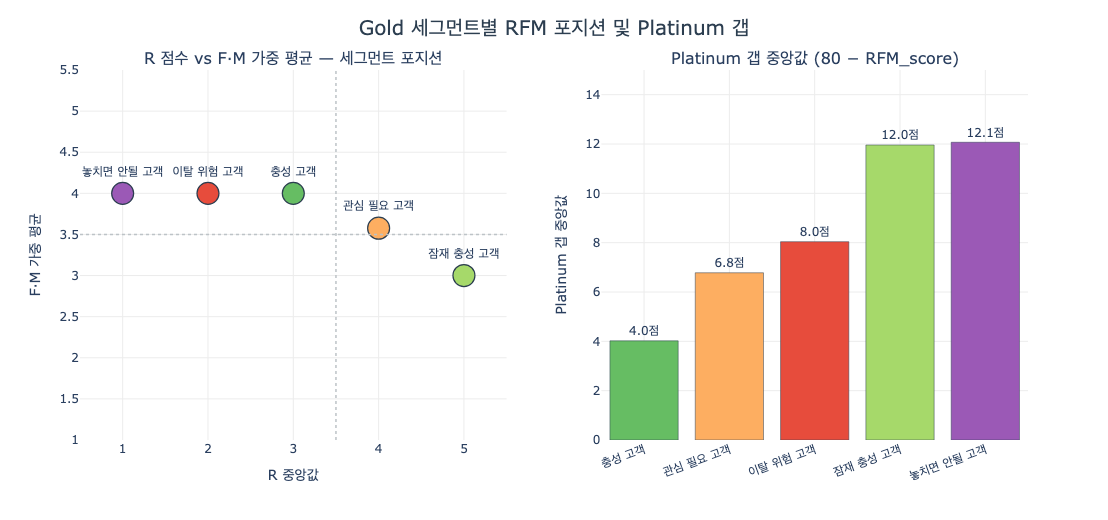

In [15]:
seg_order_h3 = ['충성 고객', '잠재 충성 고객', '관심 필요 고객', '이탈 위험 고객', '놓치면 안될 고객']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'R 점수 vs F·M 가중 평균 — 세그먼트 포지션',
        'Platinum 갭 중앙값 (80 − RFM_score)'
    ],
    column_widths=[0.5, 0.5]
)

for seg in seg_order_h3:
    row = seg_rfm_stats[seg_rfm_stats['세그먼트'] == seg].iloc[0]
    fm_weighted = (row['F_중앙값'] * 0.339 + row['M_중앙값'] * 0.460) / (0.339 + 0.460)
    fig.add_trace(go.Scatter(
        x=[row['R_중앙값']],
        y=[fm_weighted],
        mode='markers+text',
        name=seg,
        marker=dict(
            color=seg_color_gold.get(seg, '#dfe6e9'),
            size=22,
            line=dict(color='#2c3e50', width=1.2)
        ),
        text=[seg],
        textposition='top center',
        showlegend=False
    ), row=1, col=1)

fig.add_vline(x=3.5, line_dash='dot', line_color='#bdc3c7', line_width=1.5, row=1, col=1)
fig.add_hline(y=3.5, line_dash='dot', line_color='#bdc3c7', line_width=1.5, row=1, col=1)

for _, row in h3_gap.iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Bar(
        x=[seg],
        y=[row['갭_중앙값']],
        text=[f"{row['갭_중앙값']:.1f}점"],
        textposition='outside',
        marker=dict(color=seg_color_gold.get(seg, '#dfe6e9'), line=dict(color='#2c3e50', width=0.5)),
        showlegend=False
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Gold 세그먼트별 RFM 포지션 및 Platinum 갭',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=520,
    margin=dict(t=70)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='R 중앙값', range=[0.5, 5.5], row=1, col=1)
fig.update_yaxes(title_text='F·M 가중 평균', range=[1, 5.5], row=1, col=1)
fig.update_xaxes(tickangle=-20, row=1, col=2)
fig.update_yaxes(title_text='Platinum 갭 중앙값', range=[0, 15], row=1, col=2)
fig.show()

> ### 가설 3 검증 결과: 부분 기각
>
> | 세그먼트 | R 중앙값 | F 중앙값 | M 중앙값 | RFM_score 중앙값 | 갭 (중앙값) | 갭 (평균) | 그룹 |
> |---------|:------:|:------:|:------:|:--------------:|:---------:|:-------:|------|
> | 충성 고객 | 3.0 | 4.0 | 4.0 | 75.98 | **4.02** | 4.17 | 안정군 |
> | 관심 필요 고객 | 4.0 | 3.0 | 4.0 | 73.22 | 6.78 | 7.74 | 이탈 위험군 |
> | 이탈 위험 고객 | 2.0 | 4.0 | 4.0 | 71.96 | 8.04 | 8.19 | 이탈 위험군 |
> | 잠재 충성 고객 | 5.0 | 3.0 | 3.0 | 68.04 | 11.96 | 11.96 | 안정군 |
> | 놓치면 안될 고객 | 1.0 | 4.0 | 4.0 | 67.93 | **12.07** | 11.88 | 이탈 위험군 |
>
> **1. Platinum 전환 갭(Gap) 분석 (가설 기각)**
> - **현황**: Platinum 등급 전환까지의 갭(Gap) 크기는 '잠재 충성'이 아닌 **'놓치면 안될' 고객 세그먼트에서 최대치**로 나타나 가설은 기각됨.
>   - **갭 중앙값 비교**: 놓치면 안될(`12.07`) > 잠재 충성(`11.96`) > 이탈 위험 (`8.04`) > 관심 필요 (`6.78`) > 충성 고객 (`4.02`)
> - **역전 원인 (PCA 가중치 효과)**: 
>   - '놓치면 안될' 고객은 `F·M = 4`로 '잠재 충성'(`F·M = 3`)보다 구매력 지표는 우수함. 
>   - 그러나 `R = 1` 극단치로 인해 **Recency 가중치(20.1%)의 손실**이 치명적으로 작용하여 최종 `RFM_score`가 더 낮게 형성된 결과임.
>
> **2. 세그먼트별 분포 및 데이터 특징**
> - **잠재 충성 고객**: 갭 중앙값과 평균이 `11.96`으로 완전히 일치함. 이는 세그먼트 내 유저들의 RFM 점수가 `68.04`라는 **단일 값에 고르게 수렴하는 균일 구조**임을 시사함.
> - **관심 필요 고객**: 갭 중앙값(`6.78`)과 평균(`7.74`)이 약 `1.0`점의 편차를 보임. 이는 소수의 'Platinum 전환 불가 고객(극단치)'이 평균을 끌어올리고 있어, 세그먼트 내부의 전환 가능성이 균등하지 않음을 의미함.
> - **충성 고객**: 갭 중앙값(`4.02`)과 평균(`4.17`)이 고르게 낮은 분포를 유지하며 **Platinum 전환 최근접 집단**으로 확인됨. 대다수 인원이 등급 상향 문턱에 밀집해 있음.
>
> **3. 비즈니스 시사점 및 맞춤형 전환 경로 (방향성 채택)**
> - 가설의 세부 수치는 기각되었으나, 타 세그먼트 대비 잠재 충성의 갭(`11.96`)이 뚜렷하며 **F·M(구매 빈도·금액) 부족이 Platinum 전환의 핵심 보틀넥(장애 요인)이라는 방향성은 데이터가 지지함.**
>
> **세그먼트별 최적 전환 경로 (Conversion Path)**
> - **충성 고객**: 기존의 구매력을 유지한 채 **R(최근성) 회복** 주도
> - **관심 필요 & 이탈 위험**: 정상 패턴 복귀를 위한 **Recency 우선 회복**
> - **잠재 충성 고객**: 객단가 및 구매 횟수 증대를 위한 **F·M 누적 유도**
> - **놓치면 안될 고객**: 고가치 유저 재참여(Re-engagement) 마케팅을 통한 **R·F·M 동시 재활성화**

---
## 가설 4 — Gold 고객의 이탈 시점은 랜덤하지 않고 특정 월에 집중될 것이다

> **가설 4**: Gold 고객 중 이탈 조짐(Recency > 90일) 고객들의 마지막 구매 시점이 특정 시기에 집중될 것이다. 집중 구간이 확인되면 그 시점에 선제적으로 개입하는 전략을 도출할 수 있다.
>
> - 기준: D·P 분석과 동일하게 Recency > 90일 = 이탈 조짐 고객
> - 검증: 이탈 조짐 고객의 마지막 구매 월 분포 + 첫 구매부터 이탈까지 체류 기간 분포

In [16]:
timing_data = run('timing')

timing_data['이탈조짐'] = timing_data['Recency'] > 90
timing_data['마지막구매월'] = pd.to_datetime(timing_data['마지막구매일']).dt.month
timing_data['체류기간'] = (
    pd.to_datetime(timing_data['마지막구매일']) - pd.to_datetime(timing_data['첫구매일'])
).dt.days
timing_data.head()

,고객ID,첫구매일,마지막구매일,Recency,이탈조짐,마지막구매월,체류기간
0,USER_0190,2019-01-01,2019-12-18,13,False,12,351
1,USER_0351,2019-01-03,2019-08-16,137,True,8,225
2,USER_0867,2019-01-03,2019-01-03,362,True,1,0
3,USER_0783,2019-01-03,2019-11-08,53,False,11,309
4,USER_1378,2019-01-04,2019-01-04,361,True,1,0


In [17]:
max_gap = run('max_gap')

timing_data = timing_data.merge(max_gap, on='고객ID', how='left')
timing_data['최대구매간격'] = timing_data['최대구매간격'].fillna(0).astype(int)
timing_data['복귀고객'] = (
    (timing_data['최대구매간격'] > 90) &
    (~timing_data['이탈조짐'])
)
timing_data.head()

,고객ID,첫구매일,마지막구매일,Recency,이탈조짐,마지막구매월,체류기간,최대구매간격,복귀고객
0,USER_0190,2019-01-01,2019-12-18,13,False,12,351,212,True
1,USER_0351,2019-01-03,2019-08-16,137,True,8,225,62,False
2,USER_0867,2019-01-03,2019-01-03,362,True,1,0,0,False
3,USER_0783,2019-01-03,2019-11-08,53,False,11,309,139,True
4,USER_1378,2019-01-04,2019-01-04,361,True,1,0,0,False


In [18]:
total_gold = len(timing_data)
total_churn = int(timing_data['이탈조짐'].sum())
total_복귀 = int(timing_data['복귀고객'].sum())
total_정상 = total_gold - total_churn - total_복귀

print(f"정상: {total_정상}명 ({total_정상/total_gold*100:.1f}%)")
print(f"이탈 후 복귀: {total_복귀}명 ({total_복귀/total_gold*100:.1f}%)")
print(f"이탈 조짐: {total_churn}명 ({total_churn/total_gold*100:.1f}%)")

churn_monthly = (
    timing_data[timing_data['이탈조짐']]
    .groupby('마지막구매월')
    .size()
    .reset_index(name='이탈고객수')
)
churn_monthly

정상: 60명 (24.7%)
이탈 후 복귀: 53명 (21.8%)
이탈 조짐: 130명 (53.5%)


,마지막구매월,이탈고객수
0,1,13
1,2,12
2,3,9
3,4,7
4,5,11
5,6,12
6,7,21
7,8,21
8,9,24


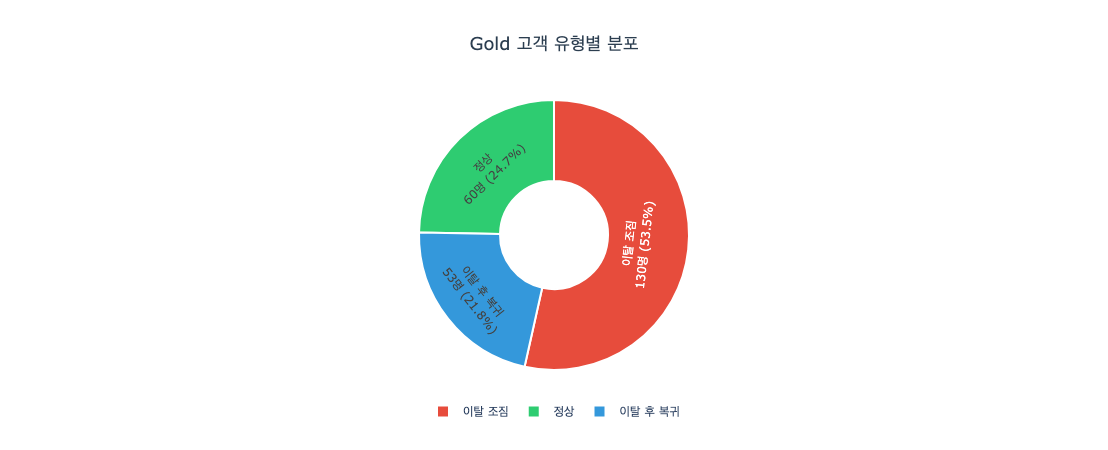

In [19]:
labels = ['정상', '이탈 후 복귀', '이탈 조짐']
values = [total_정상, total_복귀, total_churn]
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig = go.Figure(go.Pie(
    labels=labels,
    values=values,
    marker=dict(colors=colors, line=dict(color='white', width=2)),
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    hole=0.4
))

fig.update_layout(
    title=dict(
        text='Gold 고객 유형별 분포',
        font=dict(size=18, color='#2c3e50'),
        x=0.5, xanchor='center'
    ),
    legend=dict(orientation='h', yanchor='top', y=-0.1, xanchor='center', x=0.5),
    height=450
)
fig.show()

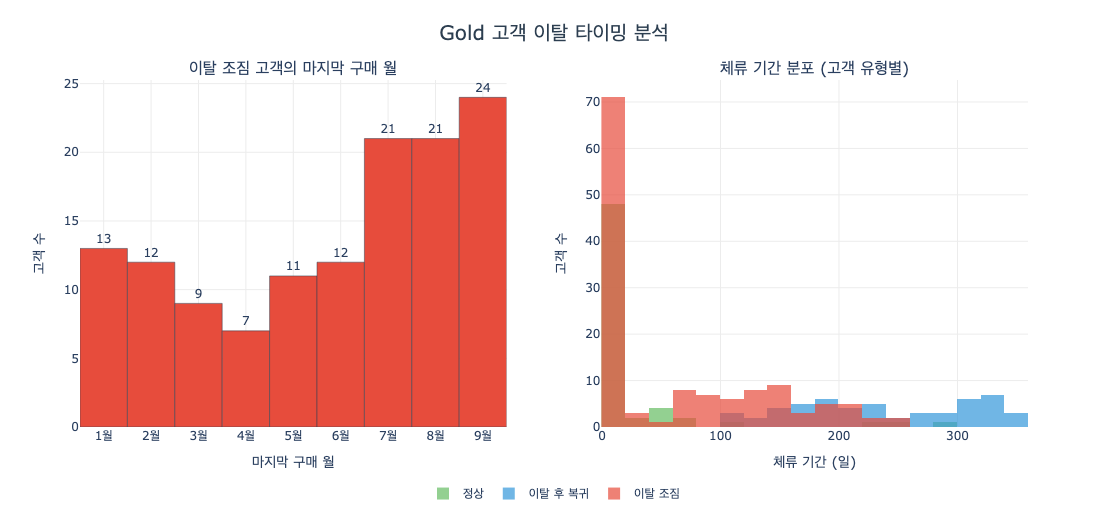

In [20]:
month_labels = {
    1: '1월', 2: '2월', 3: '3월', 4: '4월', 5: '5월', 6: '6월',
    7: '7월', 8: '8월', 9: '9월', 10: '10월', 11: '11월', 12: '12월'
}
churn_monthly['월'] = churn_monthly['마지막구매월'].map(month_labels)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['이탈 조짐 고객의 마지막 구매 월', '체류 기간 분포 (고객 유형별)']
)

fig.add_trace(go.Bar(
    x=churn_monthly['월'],
    y=churn_monthly['이탈고객수'],
    marker=dict(color='#e74c3c', line=dict(color='#2c3e50', width=0.5)),
    text=churn_monthly['이탈고객수'],
    textposition='outside',
    showlegend=False
), row=1, col=1)

hist_groups = [
    (timing_data[~timing_data['이탈조짐'] & ~timing_data['복귀고객']]['체류기간'], '#66bd63', '정상'),
    (timing_data[timing_data['복귀고객']]['체류기간'], '#3498db', '이탈 후 복귀'),
    (timing_data[timing_data['이탈조짐']]['체류기간'], '#e74c3c', '이탈 조짐'),
]
for sub, color, name in hist_groups:
    fig.add_trace(go.Histogram(
        x=sub,
        name=name,
        marker_color=color,
        opacity=0.7,
        nbinsx=15
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Gold 고객 이탈 타이밍 분석',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=520,
    barmode='overlay',
    margin=dict(t=80, b=60),
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='마지막 구매 월', row=1, col=1)
fig.update_xaxes(title_text='체류 기간 (일)', row=1, col=2)
fig.update_yaxes(title_text='고객 수', row=1, col=1)
fig.update_yaxes(title_text='고객 수', row=1, col=2)
fig.show()

> ### 가설 4 검증 결과: 부분 채택
>
> | 구분 | 고객 수 | 비중 |
> | :---: | :---: | :---: |
> | 정상 (최대 간격 ≤ `90일`) | 60명 | 24.7% |
> | 이탈 후 복귀 (간격 > `90일`, 복귀) | 53명 | 21.8% |
> | 이탈 조짐 (Recency > `90일`) | 130명 | 53.5% |
> | **전체** | **243명** | **100%** |
>
> **1. 장기 공백 경험률 분석**
> - **현황**: Gold 등급 고객의 **`75.3%`(`183명` / `243명`)** 가 연중 최소 1회 이상 `90일`을 초과하는 구매 공백을 경험함.
> - **데이터 특징**: 연말 기준 미방문 상태인 '이탈 조짐' 고객은 `53.5%`이나, 연중 이탈 후 복귀한 고객(`21.8%`)을 포함할 경우 **실제 침묵을 경험한 고가치 유저의 비율은 압도적으로 높게 형성됨.** 이는 리텐션 방어 개입이 매우 시급함을 시사함.
>
> **2. 월별 이탈 시점 및 선택 효과 (Selection Effect) 검증**
> - **여름철 이탈 집중 패턴**: 이탈 조짐 고객의 마지막 구매 월을 추적한 결과, **`7월`과 `8월`이 각 `21명`으로 상반기 월평균(`10.7명`)의 약 2배**에 달함. 특정 인위적 필터링 효과 없이 여름 시즌 구매 후 복귀하지 않은 유저가 집중된 실질적 패턴으로 확인됨.
> - **`9월`(`24명`) 데이터의 왜곡성**: `9월` 수치의 경우, Recency `90일` 기준 컷오프(연말 기점) 직전 달에 해당함. 이에 따라 해당 월 구매자 전원이 기계적으로 '이탈 조짐'으로 분류되는 **선택 효과가 작용**한 것으로 판단됨.
>
> **⚠️ 데이터 해석의 한계점 (Data Limitation)**
> - 단년도(`1개년`) 데이터의 특성상, 본 분석에서 도출된 `7-8월` 이탈 집중 현상이 매년 반복되는 **실제 계절성(Seasonality)인지 여부는 다년도 누적 데이터를 통한 추가 재검증이 요구됨.**

---
## 가설 4-1 — Gold 내 이탈 조짐 고객은 RFM 점수 하한(65점쪽)에 더 많이 집중될 것이다

> **가설 4-1** Gold 내에서 "겨우 Gold" 고객(65점쪽, 하한 근처)이 "곧 Platinum" 고객(80점쪽, 상한 근처)보다 이탈 조짐(Recency > 90일) 비율이 높을 것이다.
>
> - 배경: 가설 4에서 7-8월 이탈이 집중됨을 확인 — 이 여름 이탈을 주도하는 RFM 구간이 어디인지 규명
> - 근거: RFM 점수가 고객 건강도를 반영하므로, 하위 Gold(65점쪽)는 상위 Gold(80점쪽)보다 이탈 위험 세그먼트 비중이 높을 것
> - 검증: 65-80점 구간을 4구간(65-68 / 68-72 / 72-76 / 76-80)으로 분할 → 구간별 이탈 조짐률 비교

In [21]:
h5_data = gold_rfm.merge(timing_data[['고객ID', '이탈조짐']], on='고객ID')
h5_data['점수구간'] = pd.cut(
    h5_data['RFM_score'],
    bins=[65, 68, 72, 76, 80],
    labels=['65-68', '68-72', '72-76', '76-80'],
    include_lowest=True
)

h5_bin = (
    h5_data.groupby('점수구간', observed=True)
    .agg(
        고객수=('고객ID', 'count'),
        이탈조짐수=('이탈조짐', 'sum')
    )
    .assign(이탈조짐률=lambda x: (x['이탈조짐수'] / x['고객수'] * 100).round(1))
    .reset_index()
)
h5_bin

,점수구간,고객수,이탈조짐수,이탈조짐률
0,65-68,54,54,100.0
1,68-72,108,33,30.6
2,72-76,59,35,59.3
3,76-80,22,8,36.4


In [22]:
(
    h5_data.groupby(['점수구간', '세그먼트'], observed=True)
    .size()
    .reset_index(name='고객수')
    .sort_values(['점수구간', '고객수'], ascending=[True, False])
    .reset_index(drop=True)
)

,점수구간,세그먼트,고객수
0,65-68,놓치면 안될 고객,36
1,65-68,관심 필요 고객,12
2,65-68,이탈 위험 고객,6
3,68-72,잠재 충성 고객,65
4,68-72,이탈 위험 고객,32
5,68-72,관심 필요 고객,11
6,72-76,충성 고객,44
7,72-76,관심 필요 고객,14
8,72-76,놓치면 안될 고객,1
9,76-80,관심 필요 고객,14


In [23]:
h5_seg = (
    h5_data.groupby(['점수구간', '세그먼트'], observed=True)
    .agg(
        고객수=('고객ID', 'count'),
        이탈조짐수=('이탈조짐', 'sum')
    )
    .assign(이탈조짐률=lambda x: (x['이탈조짐수'] / x['고객수'] * 100).round(1))
    .reset_index()
)
h5_seg

,점수구간,세그먼트,고객수,이탈조짐수,이탈조짐률
0,65-68,관심 필요 고객,12,12,100.0
1,65-68,놓치면 안될 고객,36,36,100.0
2,65-68,이탈 위험 고객,6,6,100.0
3,68-72,관심 필요 고객,11,1,9.1
4,68-72,이탈 위험 고객,32,32,100.0
5,68-72,잠재 충성 고객,65,0,0.0
6,72-76,관심 필요 고객,14,0,0.0
7,72-76,놓치면 안될 고객,1,1,100.0
8,72-76,충성 고객,44,34,77.3
9,76-80,관심 필요 고객,14,0,0.0


In [24]:
h5_plot = h5_data.copy()

r_intervals = pd.qcut(h5_plot['Recency'], q=[0, 0.2, 0.4, 0.6, 0.8, 1.0])
r_left = r_intervals.apply(lambda x: x.left).astype(float).clip(lower=0)
r_right = r_intervals.apply(lambda x: x.right).astype(float)
h5_plot['R_scale'] = (h5_plot['R'] - 1) + (h5_plot['Recency'] - r_left - 0.01) / (r_right - r_left) - 0.0001

f_q1 = h5_plot['Frequency'].quantile(0.25)
f_q2 = h5_plot['Frequency'].quantile(0.50)
f_q3 = h5_plot['Frequency'].quantile(0.75)
f_upper = f_q3 + 1.5 * (f_q3 - f_q1)
f_intervals = pd.cut(
    h5_plot['Frequency'],
    bins=[0, f_q1, f_q2, f_q3, f_upper, h5_plot['Frequency'].max()]
)
f_left = f_intervals.apply(lambda x: x.left).astype(float)
f_right = f_intervals.apply(lambda x: x.right).astype(float)
h5_plot['F_scale'] = (h5_plot['F'] - 1) + (h5_plot['Frequency'] - f_left - 0.01) / (f_right - f_left) - 0.0001

np.random.seed(42)
h5_plot['R_scale'] += np.random.uniform(-0.1, 0.1, len(h5_plot))
h5_plot['F_scale'] += np.random.uniform(-0.1, 0.1, len(h5_plot))

h5_plot[['고객ID', 'R', 'F', 'R_scale', 'F_scale', 'Recency', 'Frequency']].head()

,고객ID,R,F,R_scale,F_scale,Recency,Frequency
0,USER_0006,2,4,1.611269,3.588804,189,44
1,USER_0015,5,3,4.524391,2.639307,10,14
2,USER_0018,3,4,2.100812,3.917230,140,24
3,USER_0028,5,3,4.758327,2.721853,17,14
4,USER_0036,5,3,4.214911,2.776915,33,13


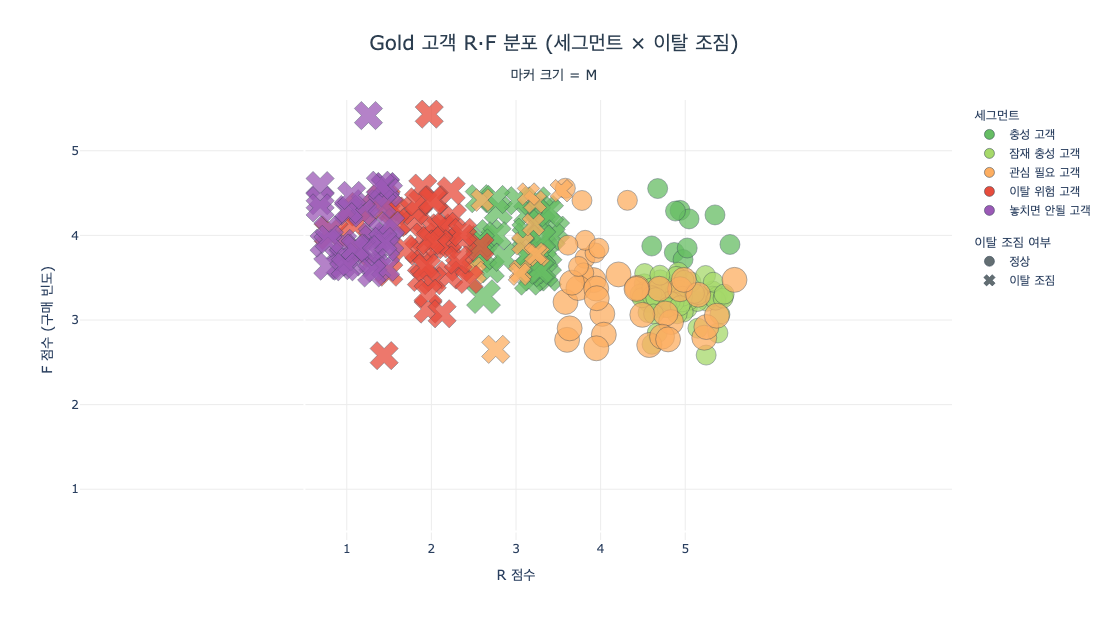

In [25]:
fig = go.Figure()

seg_list = ['충성 고객', '잠재 충성 고객', '관심 필요 고객', '이탈 위험 고객', '놓치면 안될 고객']
symbol_map = {False: 'circle', True: 'x'}

# 데이터 트레이스 (legend 미표시)
for seg in seg_list:
    for is_churn in [False, True]:
        sub = h5_plot[(h5_plot['세그먼트'] == seg) & (h5_plot['이탈조짐'] == is_churn)]
        if len(sub) == 0:
            continue
        fig.add_trace(go.Scatter(
            x=sub['R_scale'],
            y=sub['F_scale'],
            mode='markers',
            name=seg,
            showlegend=False,
            marker=dict(
                color=seg_color_gold[seg],
                symbol=symbol_map[is_churn],
                size=sub['M'] * 5 + 5,
                opacity=0.75,
                line=dict(color='#2c3e50', width=0.5)
            )
        ))

# 세그먼트 legend
for seg in seg_list:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        name=seg,
        legendgroup='세그먼트',
        legendgrouptitle=dict(text='세그먼트'),
        marker=dict(
            color=seg_color_gold[seg],
            symbol='circle',
            size=10,
            line=dict(color='#2c3e50', width=0.5)
        )
    ))

# 이탈조짐 legend
for is_churn, symbol, label in [(False, 'circle', '정상'), (True, 'x', '이탈 조짐')]:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        name=label,
        legendgroup='이탈조짐',
        legendgrouptitle=dict(text='이탈 조짐 여부'),
        marker=dict(
            color='#636e72',
            symbol=symbol,
            size=10,
            line=dict(color='#2c3e50', width=0.5)
        )
    ))

fig.update_layout(
    title=dict(
        text='Gold 고객 R·F 분포 (세그먼트 × 이탈 조짐)<br><sub>마커 크기 = M</sub>',
        font=dict(size=20, color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='R 점수',
        gridcolor='#ececec',
        tickvals=[0.5, 1.5, 2.5, 3.5, 4.5],
        ticktext=['1', '2', '3', '4', '5'],
        range=[-0.1, 5.1]
    ),
    yaxis=dict(
        title='F 점수 (구매 빈도)',
        gridcolor='#ececec',
        tickvals=[0.5, 1.5, 2.5, 3.5, 4.5],
        ticktext=['1', '2', '3', '4', '5'],
        scaleanchor='x',
        scaleratio=1,
        range=[-0.1, 5.1]
    ),
    plot_bgcolor='white',
    width=820,
    height=620,
    legend=dict(
        x=1.02, y=1,
        xanchor='left', yanchor='top',
        tracegroupgap=12
    )
)
fig.show()

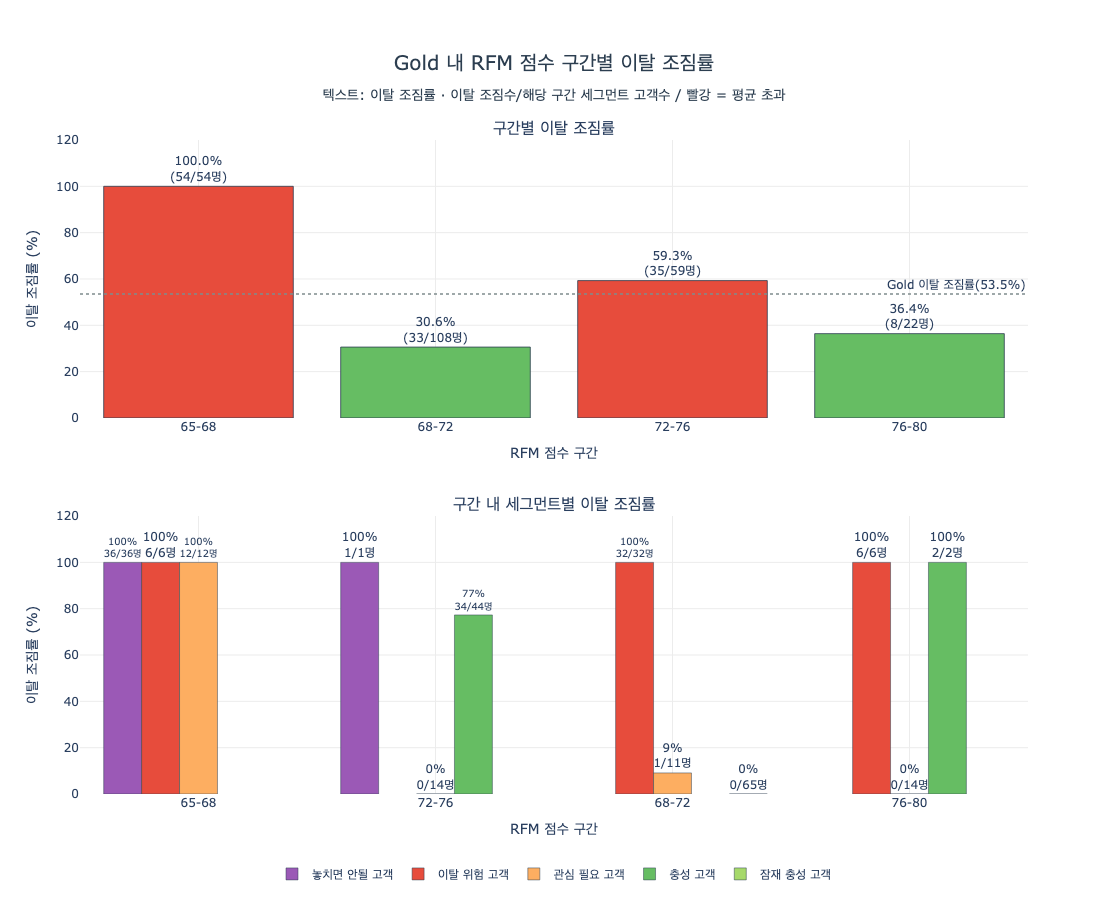

In [26]:
from plotly.subplots import make_subplots

avg_rate = round(h5_data['이탈조짐'].mean() * 100, 2)
colors_top = [
    '#e74c3c' if rate > avg_rate else '#66bd63'
    for rate in h5_bin['이탈조짐률']
]

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['구간별 이탈 조짐률', '구간 내 세그먼트별 이탈 조짐률'],
    vertical_spacing=0.15
)

# Row 1: 구간별 집계
fig.add_trace(
    go.Bar(
        x=h5_bin['점수구간'].astype(str),
        y=h5_bin['이탈조짐률'],
        text=[
            f"{row['이탈조짐률']:.1f}%<br>({int(row['이탈조짐수'])}/{int(row['고객수'])}명)"
            for _, row in h5_bin.iterrows()
        ],
        textposition='outside',
        marker=dict(color=colors_top, line=dict(color='#2c3e50', width=0.8)),
        showlegend=False
    ),
    row=1, col=1
)

# Row 2: 구간 × 세그먼트 그룹 바
seg_order = ['놓치면 안될 고객', '이탈 위험 고객', '관심 필요 고객', '충성 고객', '잠재 충성 고객']
for seg in seg_order:
    sub = h5_seg[h5_seg['세그먼트'] == seg]
    if len(sub) == 0:
        continue
    fig.add_trace(
        go.Bar(
            x=sub['점수구간'].astype(str),
            y=sub['이탈조짐률'],
            name=seg,
            marker=dict(color=seg_color_gold[seg], line=dict(color='#2c3e50', width=0.5)),
            text=[f"{v:.0f}%<br>{n}/{t}명" for v, n, t in zip(sub['이탈조짐률'], sub['이탈조짐수'], sub['고객수'])],
            textposition='outside'
        ),
        row=2, col=1
    )

fig.add_hline(
    y=avg_rate,
    line_dash='dot',
    line_color='#7f8c8d',
    line_width=1.5,
    annotation_text=f'Gold 이탈 조짐률({avg_rate}%)',
    annotation_position='top right',
    row=1, col=1
)

fig.update_layout(
    title=dict(
        text='Gold 내 RFM 점수 구간별 이탈 조짐률<br><sub>텍스트: 이탈 조짐률 · 이탈 조짐수/해당 구간 세그먼트 고객수 / 빨강 = 평균 초과</sub>',
        font=dict(size=20, color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    barmode='group',
    plot_bgcolor='white',
    margin=dict(t=140),
    width=1000,
    height=900,
    legend=dict(
        orientation='h',
        yanchor='top',
        y=-0.1,
        xanchor='center',
        x=0.5
    )
)
fig.update_xaxes(title_text='RFM 점수 구간', gridcolor='#ececec', row=1, col=1)
fig.update_yaxes(title_text='이탈 조짐률 (%)', gridcolor='#ececec', range=[0, 120], row=1, col=1)
fig.update_xaxes(title_text='RFM 점수 구간', gridcolor='#ececec', row=2, col=1)
fig.update_yaxes(title_text='이탈 조짐률 (%)', gridcolor='#ececec', range=[0, 120], row=2, col=1)
fig.show()

> ### 가설 4-1 검증 결과: 기각 (비선형 패턴 발견)
>
> | 점수 구간 | 고객수 | 이탈 조짐수 | 이탈 조짐률 | 주요 세그먼트 구성 |
> | :---: | :---: | :---: | :---: | :--- |
> | 65-68 | 54명 | 54명 | **100.0%** | 놓치면 안될(36) · 관심 필요(12) · 이탈 위험(6) |
> | 68-72 | 108명 | 33명 | 30.6% | 잠재 충성(65) · 이탈 위험(32) · 관심 필요(11) |
> | 72-76 | 59명 | 35명 | **59.3%** | 충성(44) · 관심 필요(14) · 놓치면 안될(1) |
> | 76-80 | 22명 | 8명 | 36.4% | 관심 필요(14) · 이탈 위험(6) · 충성(2) |
>
> **핵심 요약**
> RFM 점수가 낮을수록 이탈 조짐률이 높다는 단조 감소 가설과 달리, **U자형 비선형 패턴**이 나타났다. 이탈 조짐률을 결정하는 것은 점수 구간 자체가 아닌 **세그먼트 구성 차이**다.
>
> - **68-72 구간 급락 (30.6%)**
>   - **현황**: 65-68(100%)에서 68-72로 넘어오며 이탈 조짐률이 69.4%p 급락한다.
>   - **원인**: 잠재 충성 고객(65명, R=5)이 해당 구간 고객의 `60.2%`를 차지합니다. Recency 중앙값이 `20.0일`에 불과한 이 집단이 구간 전체 이탈 조짐률을 희석시킨다.
>
> - **72-76 구간 반등 (59.3%)**
>   - **현황**: 68-72 구간 대비 이탈 조짐률이 28.7%p 반등한다.
>   - **원인**: 충성 고객(44명, R=3)이 해당 구간의 `74.6%`를 점유합니다. 충성 고객의 Recency 중앙값은 `115.5일`로, 과거 구매 충성도는 높지만 최근 침묵에 들어선 비율이 상당하다.
>
> - **가설 4와의 연결 — 여름 이탈 주도층 규명**
>   - **현황**: 이탈 위험 고객(Recency 중앙값 `190.5일` · 평균 `203.0일`)은 65-68, 68-72, 76-80 구간에 걸쳐 분포하며 각 구간 이탈 조짐률 상승의 핵심 원인이다.
>   - **데이터 특징**: Recency 평균이 중앙값보다 `12일` 높아 소수의 극단 장기 미방문 고객이 존재하나, 분포 중심은 `190일` 수준이다. 이는 마지막 구매 시점이 **6-7월**에 해당하며, 가설 4에서 확인한 **7-8월 여름 이탈 집중 패턴의 실질 주도층**으로 식별된다.
>   - **통합 해석**: 두 가설은 동일한 고객군을 시점(가설 4: 언제 이탈했나)과 구간(가설 4-1: 누가 이탈했나)으로 각각 관찰한 **상호 보완적 결과**다.

---
## 결론 및 핵심 인사이트

Gold는 전체 고객의 **16.56%(243명)**, 매출 **24.34%** 를 담당하는 핵심 중간층이다. 재방문율 74.1%은 Diamond(94.8%)·Platinum(88.3%) 대비 14-21%p 낮으며, 안정군(45.6%)과 이탈 위험군(54.3%)이 공존하는 양면적 구조다.

---

### 발견 1 — Recency가 고빈도 세그먼트를 가르는 핵심 변수다 _(가설 1·2)_

놓치면 안될·이탈 위험·충성 고객은 Frequency 중앙값(32.0)과 Monetary(`$5-6K` 수준)가 거의 동일하다. **세 세그먼트를 가르는 핵심 변수는 Recency다** — F·M이 거의 동일해 Recency가 핵심 요인으로 수렴한다.

- **Recency 비교**: 316.0일(놓치면 안될) · 190.5일(이탈 위험) · 115.5일(충성)
- **놓치면 안될**: 중앙값·평균(316.0일·314.4일)이 거의 동일 — 아웃라이어가 아닌 **구성원 대부분이 고르게 장기 침묵** 상태. Monetary는 `$6,169`(이탈 위험)에 이어 2위(`$5,714`) — Recency 손실이 RFM 점수를 끌어내린 결과
- **이탈 위험**: 재방문율 86.4%로 충성(87.0%)에 버금 — 예상과 달리 **Gold 재방문율(74.1%) 저하의 실제 원인은 놓치면 안될 고객(56.8%)**

---

### 발견 2 — Gold 이탈은 구조적 패턴이며 7-8월에 집중된다 _(가설 4·4-1)_

Gold 고객 **75.3%(183/243명)** 가 연중 한 번 이상 90일+ 공백을 경험한다 — 이탈은 예외가 아닌 구조적 특성이다.

- **여름 집중**: 이탈 조짐 고객(130명)의 마지막 구매가 **7·8월 각 21명** — 상반기 월평균(10.7명)의 약 2배
- **주도층**: 이탈 위험 고객(Recency 중앙값 190.5일·평균 203.0일)의 마지막 구매는 역산 시 **6-7월**에 해당
- **비선형 패턴**: 구간별 이탈 조짐률이 U자형으로 나타남(65-68: **100%** → 68-72: 30.6% → 72-76: **59.3%** → 76-80: 36.4%) — **점수 구간이 아닌 세그먼트 구성**이 이탈 조짐률을 결정

---

### 발견 3 — Platinum 전환 경로는 세그먼트마다 다르다 _(가설 3)_

| 세그먼트 | 갭 (중앙값) | 갭 (평균) | 분포 해석 | 전환 경로 |
|---------|:----------:|:-------:|---------|---------|
| 충성 고객 | **4.02점** | 4.17점 | 평균≈중앙값 → 고르게 낮음 | R 한 단계 회복 |
| 관심 필요 고객 | 6.78점 | 7.74점 | 평균>중앙값 → 일부 고갭 고객 존재 | Recency 회복 |
| 이탈 위험 고객 | 8.04점 | 8.19점 | 평균≈중앙값 → 고르게 분포 | Recency 회복 |
| 잠재 충성 고객 | 11.96점 | 11.96점 | 완전 동일 → 단일 값 수렴 | F·M 누적 |
| 놓치면 안될 고객 | 12.07점 | 11.88점 | 평균<중앙값 → 일부 소갭 고객 존재 | 재참여 후 R·F·M 동시 회복 |

**충성 고객(갭 4.02)이 Gold 내 Platinum 전환 최근접** — 평균≈중앙값으로 대부분이 문턱 근처에 고르게 분포한다. 잠재 충성·놓치면 안될(갭 약 12)의 전환에는 상당한 시간·노력이 필요하며, 단일 캠페인이 아닌 **세그먼트별 맞춤 전환 경로**가 요구된다.

---

> **Gold 등급 방어 핵심 전략**
>
> 1. **7-8월 선제 대응**: 5-6월 기점으로 이탈 위험·관심 필요 고객(95명) 집중 모니터링 — 마지막 구매 후 60-90일 시점 리텐션 개입
> 2. **Platinum 전환 경로 분리**: 충성(R 회복) / 잠재 충성(F·M 누적) / 이탈 위험(Recency 회복) — 단일 캠페인이 아닌 세그먼트별 맞춤 접근
> 3. **놓치면 안될 고객 개인화 재참여**: Recency 중앙값·평균 모두 316일 수준의 장기 미구매 — 과거 구매 품목 기반 메시지 + 복귀 쿠폰 (일반 쿠폰 대비 A/B 테스트 우선 검증 권장)

> ✅ **액션 아이템**
>
>
> **충성 고객 — Platinum 전환 최근접 (46명, 갭 중앙값 4.02·평균 4.17)**
> - Gold 내 Platinum 갭이 가장 작음 — R 한 단계 회복만으로 전환 진입 가능
> - Recency 중앙값 115.5일로 이탈 조짐 경계(90일)를 막 넘기 시작한 구간 — "Platinum까지 X점 남았습니다" 등급 전환 알림이 재방문 동기 유발에 효과적
>
>
> **관심 필요 고객 — 전환 가능성 상위 (51명, 갭 중앙값 6.78·평균 7.74)**
> - 이탈 위험 고객보다 Platinum에 더 가까운 세그먼트 — R=4로 Recency가 아직 살아 있는 상태
> - 갭 평균(7.74)이 중앙값(6.78)보다 높아 일부 고객은 전환까지 더 많은 노력이 필요
>
>
> **이탈 위험 고객 — Platinum 전환 후보 (44명)**
> - Recency 회복 시 Platinum 문턱(80점) 도달 — 마지막 구매 후 60-90일 시점 선제 접촉
> - F·M=5인 고객: 재방문 1회로 바로 Platinum 진입 가능 → 즉시 개인화 재방문 유도
>
>
> **잠재 충성 고객 (65명)**
> - Platinum 전환 경로: F·M 누적이 유일 — "Platinum까지 X번 더 구매" 진행률 알림
> - R=5(최근성 최고)로 접점이 살아있는 상태 / 갭 중앙값·평균 11.96으로 고르게 분포
>
>
> **놓치면 안될 고객 (37명)**
> - Recency 중앙값·평균 모두 316일 수준: 1-2월 구매 후 장기 미구매 — 과거 구매 품목 기반 개인화 재참여 메시지 + 복귀 쿠폰
> - R=1로 Platinum 갭이 크므로 재참여 후 R·F·M 동시 회복 경로 필요
>
>
> **고위험 구간 우선 이탈 방어 (65-68 · 72-76)**
> - **65-68 (100%, 54명)**: 놓치면 안될·이탈 위험 집중 — 이미 침묵 상태, 즉시 재참여 개입 필요
> - **72-76 (59.3%, 59명)**: 충성 고객 이탈 주의 — Recency 회복 시 Platinum 근접, 선제 알림 효과적
> - 등급 유지 혜택 리마인더 + Recency > 90일 도달 전 구간별 맞춤 접촉
>
>
> **Gold 전체 공통 (75.3%가 연중 장기 공백 경험)**
> - 쿠폰 의존도 세그먼트 간 동질적(45-49%) — 쿠폰보다 **등급 배지·전용 혜택**으로 차별화
> - 이탈 조짐 고객 월별 모니터링 체계 수립 — **7-8월 여름 이탈 집중** 선제 대응 (다년도 데이터로 실제 계절성 재검증 필요)

---

> 🧪 **A/B 테스트 제안**
>
> - **실험 단위**: 고객 단위 랜덤 할당
> - **표본 한계**: Gold 243명(잠재 충성 65명, 관심 필요 51명, 충성 46명, 이탈 위험 44명, 놓치면 안될 37명) — 세그먼트당 표본이 적어 6개월 이상 누적 후 최종 판단 권장
>
> ---
>
> **충성 고객 — 등급 전환 알림 효과 (46명)**
> - 가설: "Platinum까지 X점 남았습니다" 전환 알림이 일반 재방문 유도 메시지보다 Platinum 전환율이 높을 것이다
> - A그룹: 일반 재방문 유도 쿠폰 / B그룹: 등급 전환 진행률 알림 + 소액 인센티브
> - **주요 지표**: 발송 후 60일 내 Platinum 전환율 / **보조 지표**: 재방문율, AOV
>
>
> **이탈 위험 고객 — 재방문 유도 타이밍 (44명)**
> - 가설: 마지막 구매 후 60-90일 시점 선제 접촉이 120일 이후보다 재방문율이 높을 것이다
> - A그룹: 120일+ 경과 후 접촉 / B그룹: 60-90일 시점 선제 메시지
> - **주요 지표**: 발송 후 30일 내 재방문율 / **보조 지표**: Platinum 전환율
>
>
> **놓치면 안될 고객 — 개인화 재참여 vs 일반 쿠폰 (37명)**
> - 가설: 과거 구매 품목 기반 개인화 메시지가 일반 쿠폰보다 복귀율이 높을 것이다
> - A그룹: 일반 할인 쿠폰 / B그룹: 구매 이력 기반 맞춤형 메시지 + 복귀 쿠폰
> - **주요 지표**: 발송 후 90일 내 재구매율 / **보조 지표**: AOV, Recency 단축 일수
>
>
> **잠재 충성 고객 — 반복 구매 인센티브 (65명)**
> - 가설: 구매 횟수 기반 진행률 알림이 Frequency 증가를 촉진할 것이다
> - A그룹: 기존 커뮤니케이션 유지 / B그룹: "Platinum까지 X번 남았습니다" 진행률 + 인센티브
> - **주요 지표**: 발송 후 60일 내 추가 구매 횟수 / **보조 지표**: Gold → Platinum 전환율